# BIBLIOTEKS

In [1]:
import re
import nltk
import random
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from imblearn.under_sampling import NearMiss
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from nltk.corpus import stopwords, wordnet as wn
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import ClusterCentroids
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [2]:
# NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Carga de carpetas (trai, val, test)

In [3]:
df_train_EDA = pd.read_csv("C:/Users/santa/OneDrive/Documentos/TT-2 MEJORADO FINAL/train_final_EDA.csv")
df_test_final = pd.read_csv("C:/Users/santa/OneDrive/Documentos/TT-2 MEJORADO FINAL/val_final.csv")
df_val_final = pd.read_csv("C:/Users/santa/OneDrive\Documentos/TT-2 MEJORADO FINAL/test_final.csv")

In [4]:
df_train_EDA.shape

(80600, 2)

In [5]:
df_train_EDA.isnull().sum()

tweet    0
clase    0
dtype: int64

C:\Users\santa\AppData\Local\Temp\ipykernel_20564\1881380495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train_EDA, x='clase', palette=['#1f77b4','#d62728'])


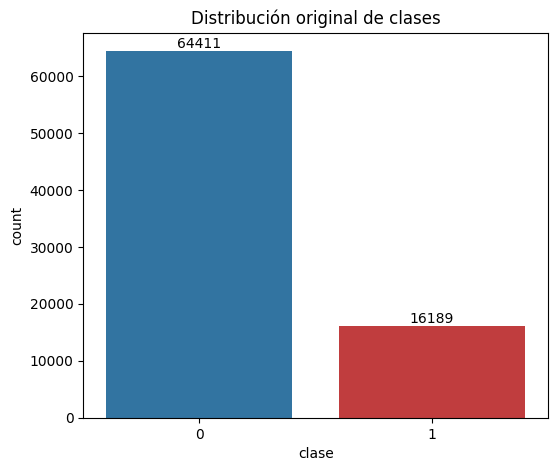

In [6]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df_train_EDA, x='clase', palette=['#1f77b4','#d62728'])
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Distribución original de clases")
plt.show()

In [7]:
df_test_final.shape

(10508, 2)

In [8]:
df_test_final.isnull().sum()

tweet    0
clase    0
dtype: int64

C:\Users\santa\AppData\Local\Temp\ipykernel_20564\2889223179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_test_final, x='clase', palette=['#1f77b4','#d62728'])


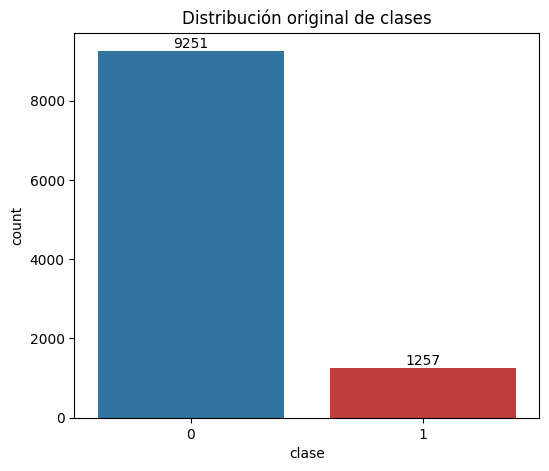

In [9]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df_test_final, x='clase', palette=['#1f77b4','#d62728'])
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Distribución original de clases")
plt.show()

In [10]:
df_val_final.shape

(20967, 2)

In [11]:
df_val_final.isnull().sum()

tweet    0
clase    0
dtype: int64

C:\Users\santa\AppData\Local\Temp\ipykernel_20564\192411694.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_val_final, x='clase', palette=['#1f77b4','#d62728'])


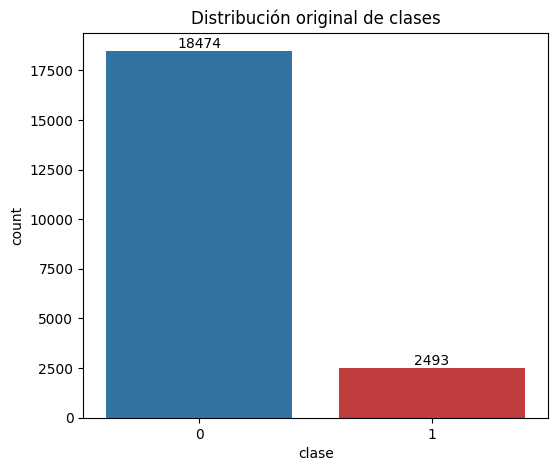

In [12]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df_val_final, x='clase', palette=['#1f77b4','#d62728'])
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Distribución original de clases")
plt.show()

# NEAR-MISS

In [13]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.8
)

X_train = vectorizer.fit_transform(
    df_train_EDA["tweet"]
)

X_val = vectorizer.transform(
    df_val_final["tweet"]
)

X_test = vectorizer.transform(
    df_test_final["tweet"]
)

y_train = df_train_EDA["clase"]
y_val = df_val_final["clase"]
y_test = df_test_final["clase"]

In [14]:
nm = NearMiss(version=1)

X_res, y_res = nm.fit_resample(X_train, y_train)

# Índices seleccionados por NearMiss
indices = nm.sample_indices_

# Recuperar tweets ORIGINALES
df_balanceado = df_train_EDA.iloc[indices].copy()

df_balanceado.to_csv(
    "df_balanceado_NM_Trans.csv",
    index=False
)

Después: Counter({0: 16189, 1: 16189})


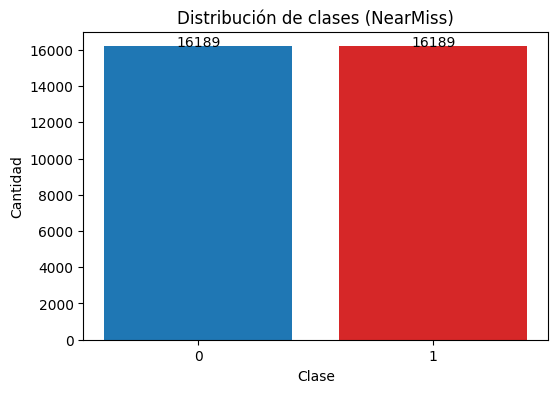

In [15]:
# Contar clases
conteo_nm = Counter(y_res)
print("Después:", conteo_nm)

# Graficar
clases = list(conteo_nm.keys())
valores = list(conteo_nm.values())

colores = ['#1f77b4' if c == 0 else '#d62728' for c in clases]
plt.figure(figsize=(6,4))
plt.bar(clases, valores, color=colores)

plt.title("Distribución de clases (NearMiss)")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(clases)

for i, v in enumerate(valores):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

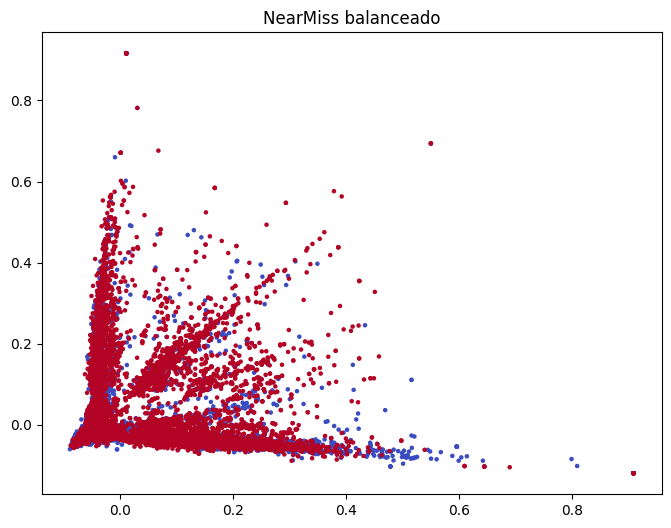

In [16]:
X_plot = PCA(n_components=2).fit_transform(X_res.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_plot[:,0], X_plot[:,1], c=y_res, cmap="coolwarm", s=5)
plt.title("NearMiss balanceado")
plt.show()

In [17]:
'''import pandas as pd

# Reconstruir textos a partir de X_res usando inverse_transform del vectorizador
resampled_words = vectorizer.inverse_transform(X_res)

# Unir las palabras para formar oraciones reconstruidas
reconstructed_tweets = [" ".join(words) for words in resampled_words]

# Crear un nuevo DataFrame con los textos reconstruidos y las clases de NearMiss
df_resampled_texts = pd.DataFrame({
    'tweet': reconstructed_tweets,
    'clase': y_res
})

# Guardar el DataFrame en un archivo CSV
df_resampled_texts.to_csv('df_balanceado_NM.csv', index=False)

print("CSV 'df_balanceado_NM.csv' creado exitosamente con los textos reconstruidos y sus clases.")'''

'import pandas as pd\n\n# Reconstruir textos a partir de X_res usando inverse_transform del vectorizador\nresampled_words = vectorizer.inverse_transform(X_res)\n\n# Unir las palabras para formar oraciones reconstruidas\nreconstructed_tweets = [" ".join(words) for words in resampled_words]\n\n# Crear un nuevo DataFrame con los textos reconstruidos y las clases de NearMiss\ndf_resampled_texts = pd.DataFrame({\n    \'tweet\': reconstructed_tweets,\n    \'clase\': y_res\n})\n\n# Guardar el DataFrame en un archivo CSV\ndf_resampled_texts.to_csv(\'df_balanceado_NM.csv\', index=False)\n\nprint("CSV \'df_balanceado_NM.csv\' creado exitosamente con los textos reconstruidos y sus clases.")'

# Clasificadores

## SVM

In [18]:
#SVM

svm = LinearSVC(
    random_state=42
)

# ENTRENAMIENTO

svm.fit(
    X_res,
    y_res
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42



 VALIDACIÓN SVM
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     18474
           1       0.53      0.78      0.63      2493

    accuracy                           0.89     20967
   macro avg       0.75      0.84      0.79     20967
weighted avg       0.92      0.89      0.90     20967



c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-package

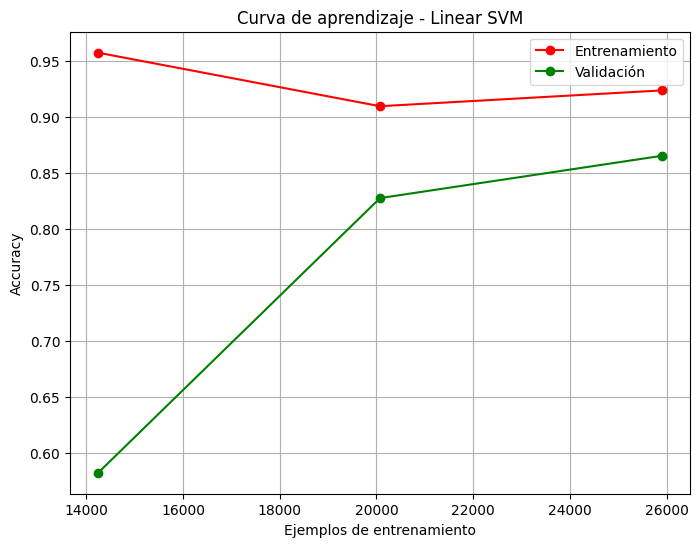

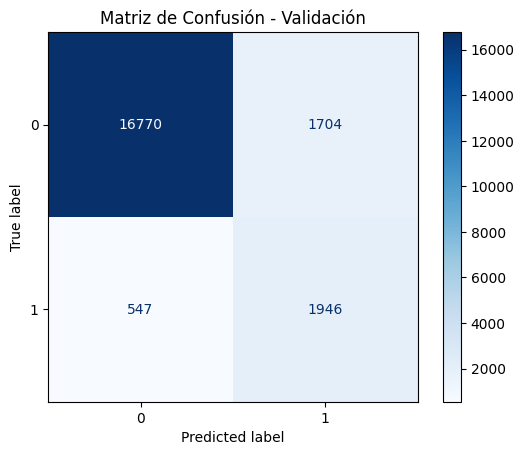

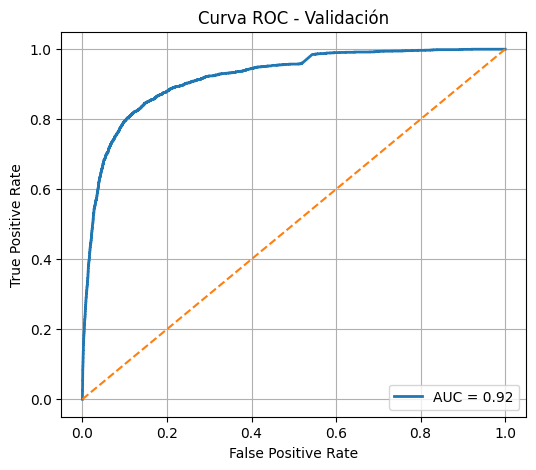

In [19]:
# VALIDACIÓN

y_pred_val = svm.predict(
    X_val
)

print("\n VALIDACIÓN SVM")
print(
    classification_report(
        y_val,
        y_pred_val
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    svm,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación'
)

plt.title("Curva de aprendizaje - Linear SVM")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN

cm = confusion_matrix(
    y_val,
    y_pred_val
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score = svm.decision_function(
    X_val
)

fpr, tpr, _ = roc_curve(
    y_val,
    y_score
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL SVM 
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      9251
           1       0.53      0.75      0.62      1257

    accuracy                           0.89     10508
   macro avg       0.75      0.83      0.78     10508
weighted avg       0.91      0.89      0.90     10508



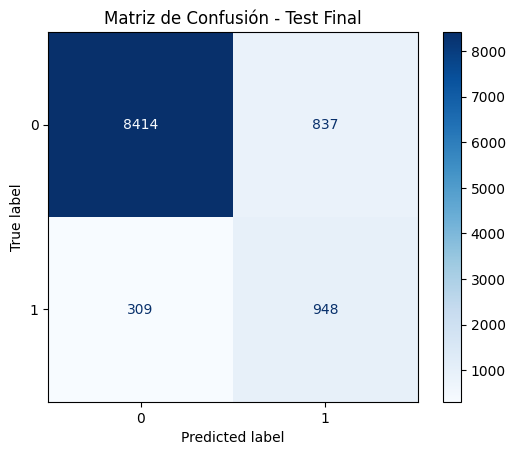

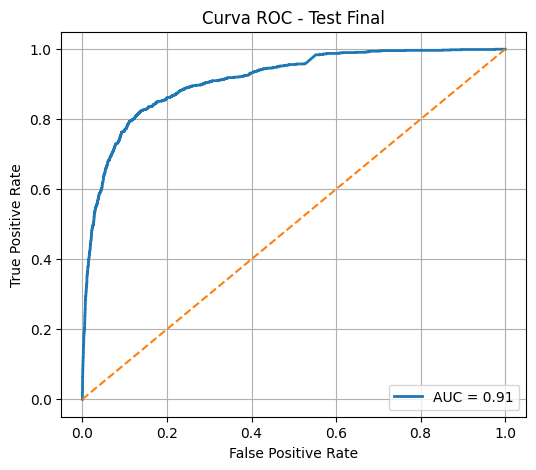

In [20]:
# TEST FINAL

y_pred_test = svm.predict(
    X_test
)

print("\n TEST FINAL SVM ")
print(
    classification_report(
        y_test,
        y_pred_test
    )
)

# MATRIZ TEST FINAL

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

#ROC TEST FINAL

y_score_test = svm.decision_function(X_test)
fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test Final")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [21]:
resultados_svm= pd.DataFrame({
    "texto": df_test_final["tweet"],
    "real": y_test,
    "prediccion": y_pred_test
})

In [22]:
correctos = resultados_svm[
    resultados_svm["real"] == resultados_svm["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - SVM NEARMISS")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for i, row in ejemplos_correctos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)

# INCORRECTOS

incorrectos = resultados_svm[
    resultados_svm["real"] != resultados_svm["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - SVM NEARMISS")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for i, row in ejemplos_incorrectos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - SVM NEARMISS

TEXTO:
presente

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
pendeja

REAL: 1
PREDICCIÓN: 1
------------------------------------------------------------


EJEMPLOS INCORRECTOS - SVM NEARMISS

TEXTO:
cuento chino sindicato prostitutas no nuevo espana no toman pelo firmantes vergonzoso manifiesto ahora abolicionistas mujeres prostituian ahora no hacen estrategias proxenetas colarnosla no cuela

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
gran suerte hombres mitad mujer mitad hombre artistas sensibles creativos racionales emotivos bendito ademas pas orquidea aprender cada dia mujeres hombres maravillos s igualdad verdad buen rollo

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------


## Regresión Logistica

In [23]:
# REGRESIÓN LOGÍSTICA

lr = LogisticRegression(
    C=5,
    max_iter=1000,
    random_state=42
)

# ENTRENAMIENTO

lr.fit(
    X_res,
    y_res
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



 VALIDACIÓN
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     18474
           1       0.55      0.78      0.65      2493

    accuracy                           0.90     20967
   macro avg       0.76      0.85      0.79     20967
weighted avg       0.92      0.90      0.91     20967



c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-package

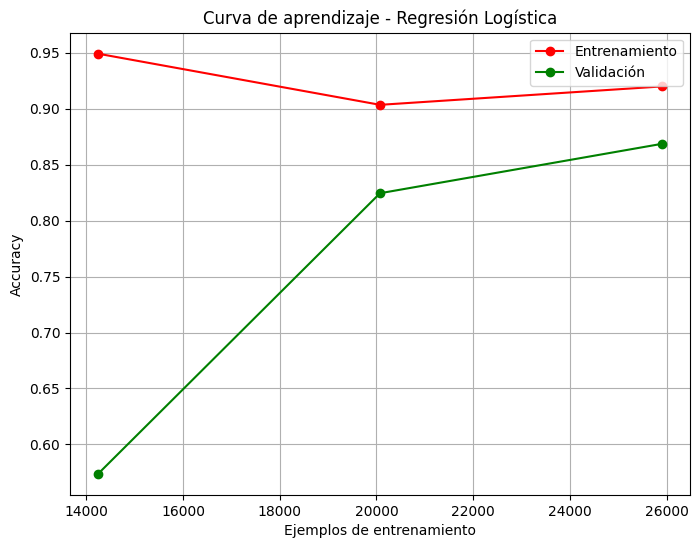

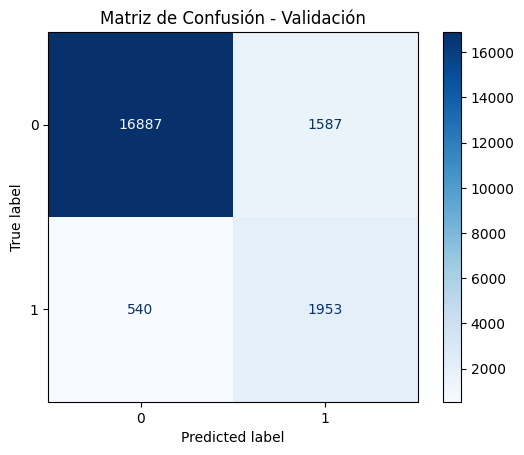

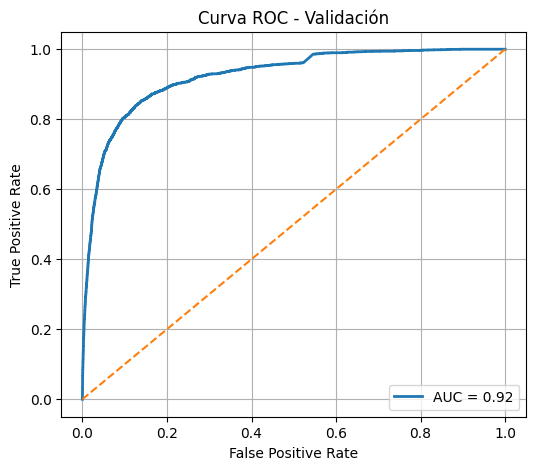

In [24]:
# VALIDACIÓN

y_pred_val_lr = lr.predict(
    X_val
)

print("\n VALIDACIÓN")
print(
    classification_report(
        y_val,
        y_pred_val_lr
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    lr,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean_lr = train_scores.mean(axis=1)
test_mean_lr = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_lr,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean_lr,
    'o-',
    color='green',
    label='Validación'
)

plt.title("Curva de aprendizaje - Regresión Logística")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN

cmlr = confusion_matrix(
    y_val,
    y_pred_val_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cmlr
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score_lr = lr.decision_function(
    X_val
)

fpr, tpr, _ = roc_curve(
    y_val,
    y_score_lr
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL REGRESIÓN LOGÍSTICA 
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      9251
           1       0.55      0.75      0.64      1257

    accuracy                           0.90     10508
   macro avg       0.76      0.84      0.79     10508
weighted avg       0.92      0.90      0.90     10508



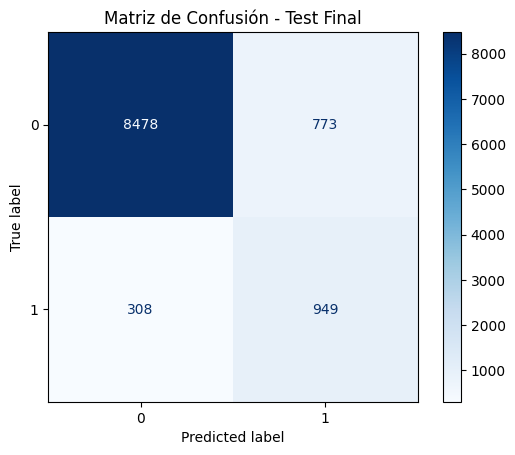

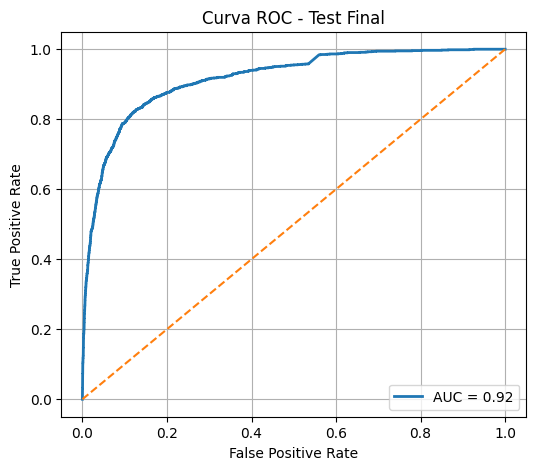

In [25]:
#TEST FINAL

y_pred_test_lr = lr.predict(
    X_test
)

print("\n TEST FINAL REGRESIÓN LOGÍSTICA ")
print(
    classification_report(
        y_test,
        y_pred_test_lr
    )
)

# MATRIZ TEST FINAL

cm_test_lr = confusion_matrix(
    y_test,
    y_pred_test_lr
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_lr
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test_lr = lr.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test_lr
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test Final")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [26]:
# EJEMPLOS CORRECTOS E INCORRECTOS

resultados_lr= pd.DataFrame({
    "texto": df_test_final["tweet"],
    "real": y_test,
    "prediccion": y_pred_test
})

In [27]:
# CORRECTOS

correctos = resultados_lr[
    resultados_lr["real"] == resultados_lr["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - REGRESIÓN LOGÍSTICA")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for _, row in ejemplos_correctos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - REGRESIÓN LOGÍSTICA

TEXTO:
tragedia panista sinaloa tal no perder dos pluris congreso local

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
minimo denle unas palabras no asi

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


In [28]:
# INCORRECTOS
incorrectos = resultados_lr[
    resultados_lr["real"]
    !=
    resultados_lr["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - REGRESIÓN LOGÍSTICA")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
    random_state=42
)

for _, row in ejemplos_incorrectos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS INCORRECTOS - REGRESIÓN LOGÍSTICA

TEXTO:
juntas periodistas feministas grosas analizar violencia genero digital salen notazas

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
hace tiempo quería escribir mujeres hollywood previo censura fin hice aquí reflexiones estrellas cine clásico relevancia entender representación perspectiva género

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------


## Naive Bayes

In [29]:
# NAIVE BAYES

nb = MultinomialNB(alpha=0.01)

# ENTRENAMIENTO

nb.fit(
    X_res,
    y_res
)

,alpha,0.01
,force_alpha,True
,fit_prior,True
,class_prior,None



 VALIDACIÓN NAIVE BAYES 
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     18474
           1       0.42      0.79      0.54      2493

    accuracy                           0.84     20967
   macro avg       0.69      0.82      0.72     20967
weighted avg       0.90      0.84      0.86     20967



c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-package

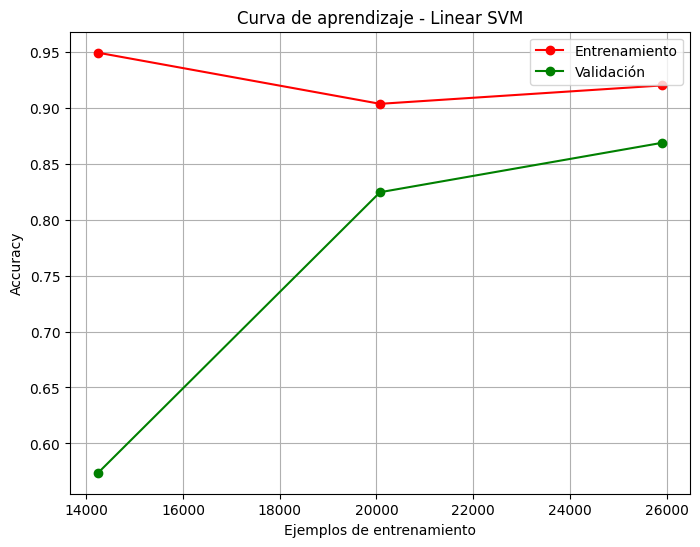

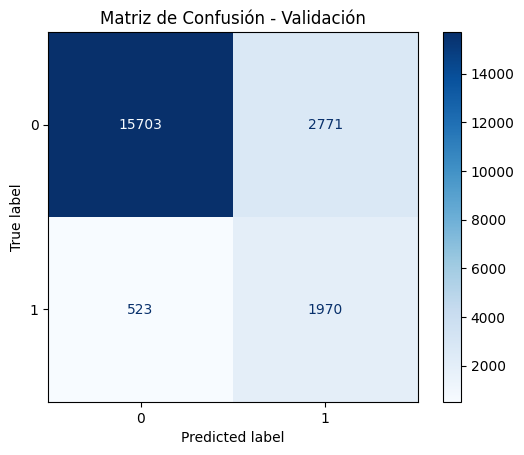

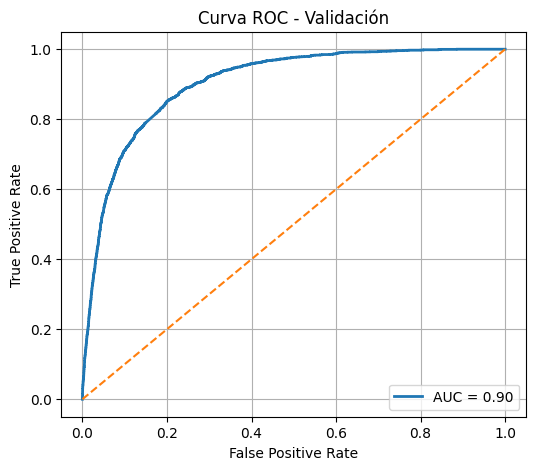

In [30]:
# VALIDACIÓN

y_pred_val_nb = nb.predict(X_val)
print("\n VALIDACIÓN NAIVE BAYES ")
print(
    classification_report(
        y_val,
        y_pred_val_nb
    )
)

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    lr,
    X_res,
    y_res,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

#Curva de aprendizaje

train_mean_nb = train_scores.mean(axis=1)
test_mean_nb = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_nb,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean_nb,
    'o-',
    color='green',
    label='Validación'
)
plt.title("Curva de aprendizaje - Linear SVM")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Matriz de Confusion

cm_val_nb = confusion_matrix(
    y_val,
    y_pred_val_nb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val_nb
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()
y_score_val_nb = nb.predict_proba(
    X_val
)[:,1]

fpr, tpr, _ = roc_curve(
    y_val,
    y_score_val_nb
)

#ROC CURVE

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Naive Bayes
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      9251
           1       0.41      0.77      0.53      1257

    accuracy                           0.84     10508
   macro avg       0.69      0.81      0.72     10508
weighted avg       0.90      0.84      0.86     10508



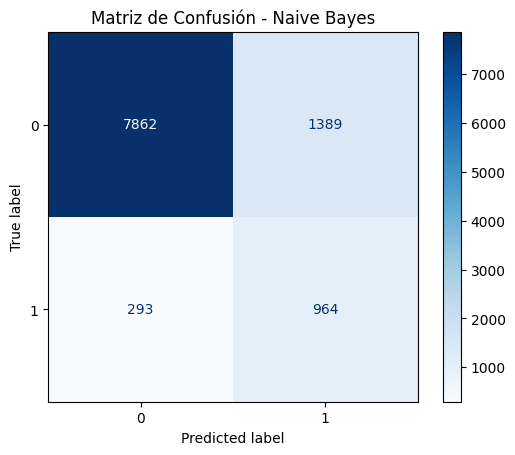

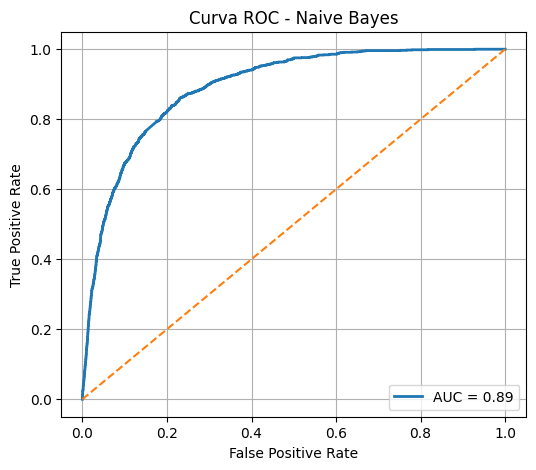

In [31]:
# PREDICCIONES

y_pred_nb = nb.predict(
    X_test
)

print("\nNaive Bayes")
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

# MATRIZ DE CONFUSIÓN

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap=plt.cm.Blues)
plt.title(
    "Matriz de Confusión - Naive Bayes"
)
plt.show()

# CURVA ROC

y_score = nb.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    y_score
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Curva ROC - Naive Bayes"
)

plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [32]:
# EJEMPLOS CORRECTOS E INCORRECTOS

resultados_nb= pd.DataFrame({
    "texto": df_test_final["tweet"],
    "real": y_test,
    "prediccion": y_pred_test
})

# CORRECTOS

correctos = resultados_nb[
    resultados_nb["real"] == resultados_nb["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - NAIVE BAYES")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for _, row in ejemplos_correctos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - NAIVE BAYES

TEXTO:
this might be longest battle ever take it next level

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
inician trabajos sesion ordinaria zona occidente puerto vallarta jalisco

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


In [33]:
# INCORRECTOS

incorrectos = resultados_nb[
    resultados_nb["real"] != resultados_nb["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - NAIVE BAYES")
print("="*60)
ejemplos_incorrectos = incorrectos.sample(
    2,
)

for _, row in ejemplos_incorrectos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS INCORRECTOS - NAIVE BAYES

TEXTO:
mujeres paledtinas bajo bloqueo ocupacion discriminacion mayo casa mujer alcorcon alcorcon

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
despues revisar caso teodora condenada anos prision aborto involuntario confirma sentencia mundo sepa teodora presa ser mujer pobre basta

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------


## MLP

In [34]:
X_train_mlp = X_res.toarray()
X_val_mlp = X_val.toarray()
X_test_mlp = X_test.toarray()
y_train_mlp = y_res
y_val_mlp = y_val
y_test_mlp = y_test

In [35]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    max_iter=40,
    random_state=42,
    verbose=True,

    # EARLY STOPPING
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

# ENTRENAMIENTO

mlp.fit(
    X_train_mlp,
    y_train_mlp
)

Iteration 1, loss = 0.47019340
Validation score: 0.874614
Iteration 2, loss = 0.27023290
Validation score: 0.876467
Iteration 3, loss = 0.23494881
Validation score: 0.872143
Iteration 4, loss = 0.21138017
Validation score: 0.872452
Iteration 5, loss = 0.18704581
Validation score: 0.875849
Iteration 6, loss = 0.16167224
Validation score: 0.875540
Iteration 7, loss = 0.13781956
Validation score: 0.876467
Iteration 8, loss = 0.11569911
Validation score: 0.874614
Iteration 9, loss = 0.09887366
Validation score: 0.873070
Iteration 10, loss = 0.08579784
Validation score: 0.873687
Iteration 11, loss = 0.07643074
Validation score: 0.874614
Iteration 12, loss = 0.06882553
Validation score: 0.872452
Iteration 13, loss = 0.06365811
Validation score: 0.874923
Iteration 14, loss = 0.05948214
Validation score: 0.873379
Iteration 15, loss = 0.05652105
Validation score: 0.873996
Iteration 16, loss = 0.05468293
Validation score: 0.873996
Iteration 17, loss = 0.05244314
Validation score: 0.874923
Iterat

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,256
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,40
,shuffle,True
,random_state,42



VALIDACIÓN MLP
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     18474
           1       0.55      0.76      0.64      2493

    accuracy                           0.90     20967
   macro avg       0.76      0.84      0.79     20967
weighted avg       0.92      0.90      0.90     20967



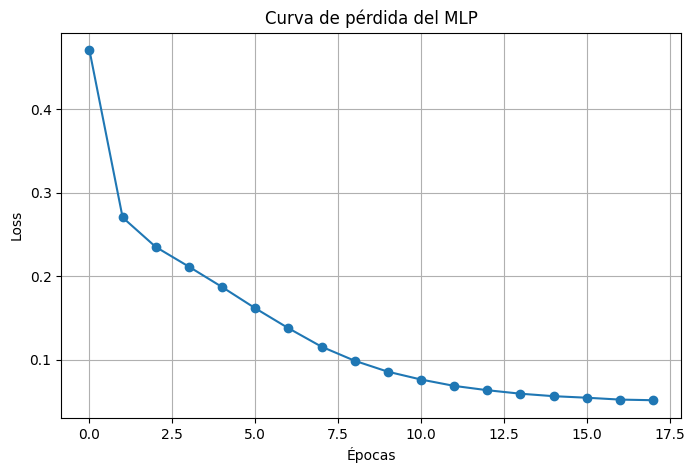

MemoryError: Unable to allocate 247. MiB for an array with shape (6475, 5000) and data type float64

In [36]:
# VALIDACIÓN

y_pred_val_mlp = mlp.predict(
    X_val_mlp
)

print("\nVALIDACIÓN MLP")

print(
    classification_report(
        y_val_mlp,
        y_pred_val_mlp
    )
)

# CURVA DE PÉRDIDA

plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_, marker='o')
plt.title("Curva de pérdida del MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(

    mlp,
    X_train_mlp,
    y_train_mlp,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación cruzada'
)

plt.title("Curva de aprendizaje del MLP")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN
cm_val = confusion_matrix(
    y_val_mlp,
    y_pred_val_mlp
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Val")
plt.show()

# ROC VALIDACIÓN
y_score_val = mlp.predict_proba(
    X_val_mlp
)[:,1]

fpr, tpr, _ = roc_curve(y_val_mlp,y_score_val)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# TEST FINAL
y_pred_test_mlp = mlp.predict(
    X_test_mlp
)

print("\nTEST FINAL MLP")

print(
    classification_report(
        y_test_mlp,
        y_pred_test_mlp
    )
)

# MATRIZ TEST FINAL
cm_test = confusion_matrix(
    y_test_mlp,
    y_pred_test_mlp
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test = mlp.predict_proba(
    X_test_mlp
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test_mlp,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# EJEMPLOS CORRECTOS E INCORRECTOS

resultados_mlp = pd.DataFrame({
    "texto": df_test_final["tweet"],
    "real": y_test,
    "prediccion": y_pred_test
})

In [ ]:
# CORRECTOS

correctos = resultados_mlp[
    resultados_mlp["real"] == resultados_mlp["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - MLP")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for _, row in ejemplos_correctos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - MLP

TEXTO:
no sé si ustedes pasa no caga demasiado dramas coreanos tailandeses japoneses chinos retractan mujer sumisa callada obediente cultura serie enferma quiero romper mesa puesta comer

REAL: 1
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
mexicano acepto armonizar garantizar derecho terminacion voluntaria embarazo mujeres victimas violacion embarazo precoz corran peligro

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


In [ ]:
# INCORRECTOS

incorrectos = resultados_mlp[
    resultados_mlp["real"] != resultados_mlp["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - MLP")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for _, row in ejemplos_incorrectos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS INCORRECTOS - MLP

TEXTO:
amet hacer permitir cualquier jerarca militar diputados aquellos endiosado estacionen mal crean tapones hacerse vista gorda pues asesores opiniones solo ven rangos coronel general no deber amet

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
teresa jesus mujer desconocida nada valorada mucha gente extraordinaria audaz epoca mayoria mujeres analfabetas funcion destino limitados

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------
